In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the Mall Customers dataset

df = pd.read_csv(
    r"C:\Users\91958\Desktop\Machine Learning\datasets\Mall_Customers.csv"
)

# Displaying the first five rows

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Statistical summary of numerical columns

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
# Statistical summary of numerical columns

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# Checking for missing values

df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Displaying dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200
Columns : 5


In [7]:
# Checking for duplicate records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
# Displaying column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [10]:
# Selecting features for clustering

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

print("Selected Features:")
display(X.head())

print("\nFeatures Shape:", X.shape)
# Displaying the selected clustering features

display(X)

Selected Features:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40



Features Shape: (200, 2)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [11]:
# Standardizing the selected features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
display(pd.DataFrame(
    X_scaled,
    columns=X.columns
).head())

Scaled Features:


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [12]:
# Checking the mean and standard deviation after scaling

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("Mean of scaled features:")
print(scaled_df.mean())

print("\nStandard deviation of scaled features:")
print(scaled_df.std())

Mean of scaled features:
Annual Income (k$)       -2.131628e-16
Spending Score (1-100)   -1.465494e-16
dtype: float64

Standard deviation of scaled features:
Annual Income (k$)        1.002509
Spending Score (1-100)    1.002509
dtype: float64


In [13]:
# Finding the optimal number of clusters using the Elbow Method

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

print("Inertia values:")
print(inertia)

Inertia values:
[400.00000000000006, 269.691012192764, 157.7040081503594, 108.92131661364358, 65.56840815571681, 55.057348270386015, 44.86475569922557, 37.228187677585886, 32.39226763033117, 29.981897788243703]


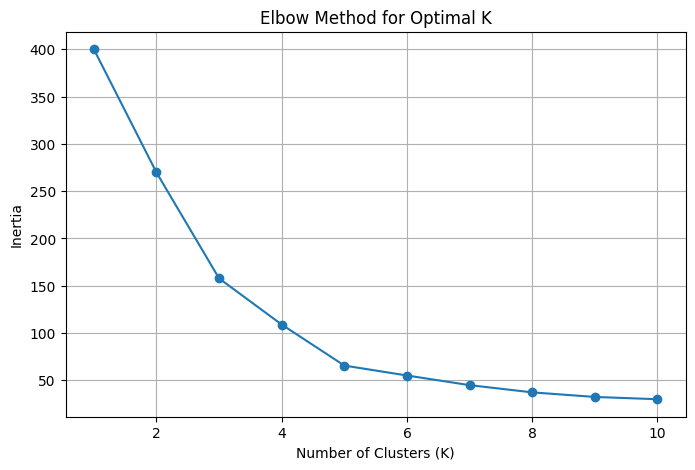

In [14]:
# Plotting the Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.grid()
plt.show()

In [15]:
# Selecting the optimal number of clusters

optimal_k = 5

print("Optimal Number of Clusters:", optimal_k)

Optimal Number of Clusters: 5


In [16]:
# Creating the K-Means clustering model

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

print("K-Means model created successfully!")

K-Means model created successfully!


In [17]:
# Training the K-Means model

kmeans.fit(X_scaled)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [18]:
# Assigning cluster labels to each customer

cluster_labels = kmeans.labels_

print("Cluster Labels:")
print(cluster_labels)

Cluster Labels:
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [19]:
# Adding cluster labels to the original dataset

df["Cluster"] = cluster_labels

display(df.head(10))

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [20]:
# Displaying cluster centers

cluster_centers_scaled = kmeans.cluster_centers_

cluster_centers = scaler.inverse_transform(
    cluster_centers_scaled
)

cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=X.columns
)

cluster_centers_df.index.name = "Cluster"

display(cluster_centers_df)

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043
